# **Digit Classification: Exploring & Optimizing CNN Performance**

> **Goal:** Identify common weaknesses of baseline ANN & CNN models using Kaggle's Digit Recognizer dataset,<br> and use these observations to optimize the architecture and parameters of the baseline CNN

**We will:**
1. Perform simple EDA to identify dataset leakage, balance, and sample content
1. Develop data pipelines and baseline models identify potential weaknesses
1. Expand and optimize the model's architecture
1. Analyze top architecture performances
1. Complete final tuning of top model architecture's hyperparameters
1. Create the Kaggle submission for the final model

**Data Location:** `data/train.csv`, `data/test.csv`<br>
**Submission:** `submissions/submissions_baseline_csv`

In [1]:
# personal gpu training
import intel_extension_for_tensorflow as itex
import tensorflow as tf

tf.config.list_physical_devices("XPU")

2026-05-10 18:19:43.863592: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-10 18:19:43.884147: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-10 18:19:43.884175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-10 18:19:43.884924: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-10 18:19:43.888881: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-10 18:19:43.889530: I tensorflow/core/platform/cpu_feature_guard.cc:1

[PhysicalDevice(name='/physical_device:XPU:0', device_type='XPU')]


# Section I: [Project Setup]

1. Project Setup & Configuration
1. Basic EDA & sanity checks
1. Load datasets from files

### Project Setup & Path Config

In [2]:
# --- import necessary libraries ---
import numpy as np
import pandas as pd
# import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import preprocessing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten  # core layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization     # cnn layers 

import os
import math
from pathlib import Path

# garbage collection for ram / space management for training on Ryan's personal gpu
import gc
from tensorflow.keras import backend as back
from IPython.display import clear_output

# --- Set seeds for reproducability --- #
seed = 42
np.random.seed(42)
tf.random.set_seed(42)

# --- Define paths, verify they exist
DATA_DIR = Path("data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SUB_PATH = "submissions/submission.csv"
MODEL_PATH = "models/optimizedCNN.keras"

os.makedirs("models", exist_ok=True)
os.makedirs("submissions", exist_ok=True)

assert TRAIN_PATH.exists(), "train.csv not found"
assert TEST_PATH.exists(), "test.csv not found"

print("Found data at:", DATA_DIR.resolve())

Found data at: /home/toast/data


### Data Loading & Sanity Checks

In [3]:
# --- Load data --- #
trainSet = pd.read_csv(TRAIN_PATH)
testSet = pd.read_csv(TEST_PATH)

print(f"Train.csv shape: {trainSet.shape}")
print(f"Test.csv shape: {testSet.shape}")

Train.csv shape: (42000, 785)
Test.csv shape: (28000, 784)


In [4]:
from sklearn.model_selection import train_test_split

# data prep; convert from pd to np.ndarray
def load_dataset():
    X = trainSet.drop(columns=["label"]).values.astype("float32") # training set is made up of 785 columns, first is label
    y = trainSet["label"].values.astype("int64")
    xSub = testSet.values.astype("float32")

    return X, y, xSub
    
# split train.csv & test.csv into data, labels and test sets
xData, yLabels, xTest = load_dataset()
print(f"Train shape: {xData.shape}, Labels: {yLabels.shape}")
print(f"Test shape: {xTest.shape}")
print(f"Missing values in train: {np.isnan(xData).sum() + np.isnan(yLabels).sum()}")
print(f"Missing values in test:  {np.isnan(xTest).sum()}")

Train shape: (42000, 784), Labels: (42000,)
Test shape: (28000, 784)
Missing values in train: 0
Missing values in test:  0


### EDA & Sample Previews

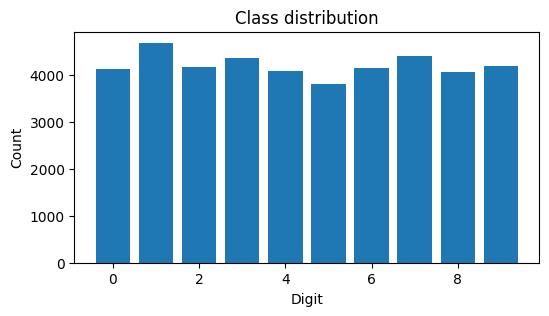

Train shape: (37800, 784), Validation shape: (4200, 784)


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

# Class distribution
vals, counts = np.unique(yLabels, return_counts=True)
plt.figure(figsize=(6,3))
plt.bar(vals, counts)
plt.title("Class distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

# split dataset into training and testing sets & 'freeze them'
xTrain, xVal, yTrain, yVal = train_test_split(xData, yLabels, test_size=0.10, random_state=seed, stratify=yLabels)
print(f"Train shape: {xTrain.shape}, Validation shape: {xVal.shape}")

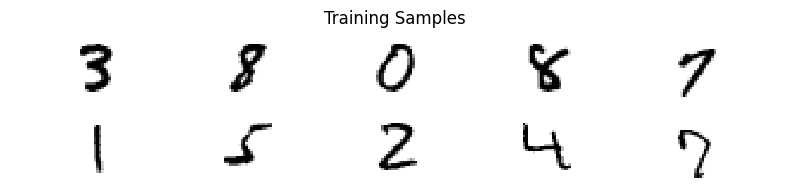

In [6]:
%matplotlib inline

# peek at some data samples
plt.figure(figsize=(8,2))
plt.title("Training Samples")
plt.axis('off')

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.axis('off')
    img = xTrain[i].reshape(28, 28)
    plt.imshow(img, cmap=plt.cm.gray_r, interpolation='nearest')


plt.tight_layout()
plt.show()

# Section II: [Data Pipelines & Baseline Models]
1. Set up basic data pipelines
1. Create baseline ANN & CNN models

#### Baseline Preprocessing:
> ANN: Normalize + Flatten<br>
> CNN: Normalize (2D Input) + Light Augmentation

Standardization tested on ANN negatively impacted performance and was dropped

### Basic Data Pipelines

In [7]:
# normalization
def ANNPipeline(xTrain, xVal, xSub):
    # data is already flattened (n, 784)
    xTr = xTrain / 255.0
    xV = xVal / 255.0
    xS = xSub / 255.0

    return xTr, xV, xS

# reshape normalized data into 28x28x1 images
# augmentation added during training
def CNNPipeline(xTrain, xVal, xSub):
    xTr = xTrain / 255.0
    xV = xVal / 255.0
    xS = xSub / 255.0
    
    xTr = xTr.reshape(-1, 28, 28, 1)
    xV = xV.reshape(-1, 28, 28, 1)
    xS = xS.reshape(-1, 28, 28, 1)

    return xTr, xV, xS

### Define Baseline Models

In [8]:
# simple 3 layer model as baseline
def baselineANN():
    model = Sequential([
        Input(shape=(784,)),
        Dense(64, activation="sigmoid"),
        Dense(128, activation="sigmoid"),
        Dense(10, activation="softmax"),
    ], name="BaselineANN")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy", 
        metrics=["accuracy"])
    return model

# unoptimized cnn used for digit recognition
def baselineCNN():
    model = Sequential([
        Input(shape=(28,28,1)),
        Conv2D(32, 3, activation="relu"),
        MaxPooling2D(),
        Conv2D(64, 3, activation="relu"),
        MaxPooling2D(),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.25),
        Dense(10, activation="softmax"),
    ], name="BaselineCNN")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    return model

# Section III: [Baseline Training]
1. Train baselines
1. compare model performance
1. Identify model weaknesses

### Baseline Training Setup

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

def make_datagen():
    return ImageDataGenerator(rotation_range=8, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1)

def make_callbacks():
    return [EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy')]

# cnn training using baseline augmentation datagen
def train_w_datagen(model, xTr, yTrain, xV, yVal, epochs=10, batch_size=128, callbacks=None):
    datagen = make_datagen()
    train_flow = datagen.flow(xTr, yTrain, batch_size=batch_size, shuffle=True)
    hist = model.fit(train_flow, validation_data=(xV, yVal), epochs=epochs, callbacks=callbacks or make_callbacks(), verbose=1)

    return hist

# save the model results into a dictionary for easy storage and access
def collect_results(model, hist, xV, yVal):
    valLoss, valAcc = model.evaluate(xV, yVal, verbose=0)
    yProb = model.predict(xV, verbose=0)
    yPred = np.argmax(yProb, axis=1)

    return {
        "val_loss" : valLoss, "val_acc" : valAcc,
         "history" : hist.history, "confusion_matrix" : confusion_matrix(yVal, yPred),
        "classification_report" : classification_report(yVal, yPred, output_dict=True, zero_division=0),
         "auc_macro_ovr" : roc_auc_score(yVal, yProb, multi_class="ovr", average="macro"),
         "y_val_pred" : yPred, "y_val_prob" : yProb,
    }

# memory management for Ryan, training on personal gpu
def cleanup_model(model=None):
    if model is not None:
        del model
    back.clear_session()
    gc.collect()

### Model Training

In [10]:
# baseline training
def trainBaseline(ann=True):
    name = ""
    model = None
    results = {}

    ep = 10

    # training baseline models with standardization (ann) & augmentation (cnn)
    if ann:
        name = "baselineANN" 
        model = baselineANN()
        xTr, xV, xS = ANNPipeline(xTrain, xVal, xTest)
        hist = model.fit(xTr, yTrain, validation_data=(xV, yVal), epochs=ep, batch_size=128, callbacks=make_callbacks(), verbose=1)
        results[name] = collect_results(model, hist, xV, yVal)
    else:
        name = "baselineCNN" 
        model = baselineCNN()
        xTr, xV, xS = CNNPipeline(xTrain, xVal, xTest)

        hist = train_w_datagen(model, xTr, yTrain, xV, yVal, epochs=ep, batch_size=128, callbacks=make_callbacks())
        results[name] = collect_results(model, hist, xV, yVal)
    
    cleanup_model(model)
    print("Training completed")

    return results

# training models
annBaseResults = trainBaseline(ann=True)
cnnBaseResults = trainBaseline(ann=False)

2026-05-10 18:19:49.422064: I tensorflow/core/common_runtime/next_pluggable_device/next_pluggable_device_factory.cc:118] Created 1 TensorFlow NextPluggableDevices. Physical device type: XPU


Epoch 1/10


2026-05-10 18:19:49.959509: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type XPU is enabled.


296/296 [==============================] - 4s 9ms/step - loss: 0.5166 - accuracy: 0.8530 - val_loss: 0.2567 - val_accuracy: 0.9231
Epoch 2/10
296/296 [==============================] - 2s 8ms/step - loss: 0.2130 - accuracy: 0.9361 - val_loss: 0.1956 - val_accuracy: 0.9395
Epoch 3/10
296/296 [==============================] - 4s 12ms/step - loss: 0.1747 - accuracy: 0.9501 - val_loss: 0.1819 - val_accuracy: 0.9479
Epoch 4/10
296/296 [==============================] - 2s 8ms/step - loss: 0.1496 - accuracy: 0.9574 - val_loss: 0.1670 - val_accuracy: 0.9538
Epoch 5/10
296/296 [==============================] - 2s 8ms/step - loss: 0.1266 - accuracy: 0.9634 - val_loss: 0.1447 - val_accuracy: 0.9536
Epoch 6/10
296/296 [==============================] - 2s 8ms/step - loss: 0.1108 - accuracy: 0.9675 - val_loss: 0.1458 - val_accuracy: 0.9576
Epoch 7/10
296/296 [==============================] - 3s 8ms/step - loss: 0.0958 - accuracy: 0.9710 - val_loss: 0.1383 - val_accuracy: 0.9598
Epoch 8/10
296/2

### Baseline Analysis Setup

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# plot the model's history, confusion matrix, and metric summary table
def getFigures(results, name):
    fig, axes = plt.subplots(2, 2, figsize=(10,7))

    # plot history
    hist = results["history"]

    axes[0][0].plot(hist["accuracy"], label="train_acc")
    axes[0][0].plot(hist["val_accuracy"], label="val_acc")
    axes[0][0].set_title(f"{name} Accuracy")
    axes[0][0].set_xlabel("Epoch")
    axes[0][0].set_ylabel("Accuracy")
    axes[0][0].legend()
    axes[0][0].grid(alpha=0.3)

    axes[0][1].plot(hist["loss"], label="train_loss")
    axes[0][1].plot(hist["val_loss"], label="val_loss")
    axes[0][1].set_title(f"{name} Loss")
    axes[0][1].set_xlabel("Epoch")
    axes[0][1].set_ylabel("Loss")
    axes[0][1].legend()
    axes[0][1].grid(alpha=0.3)

    # plot confusion matrix
    cm = results["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1][0]) 
    axes[1][0].set_title(f"{name}: Confusion Matrix")
    axes[1][0].set_ylabel('Actual Label')
    axes[1][0].set_xlabel('Predicted Label')

    # plot metric table
    report = results["classification_report"]
    metrics_df = pd.DataFrame({
        "Metric" : ["val_acc", "macro_precision", "macro_f1", "macro_recall", "auc_macro_ovr"],
        "Value" : [ results["val_acc"],
                    report["macro avg"]["precision"],
                    report["macro avg"]["f1-score"],
                    report["macro avg"]["recall"],
                    results["auc_macro_ovr"]
        ]
    })

    axes[1][1].axis("off")
    table = axes[1][1].table(
        cellText=metrics_df.round(4).values,
        colLabels=metrics_df.columns,
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(15)
    table.scale(1.2, 1.5)
    axes[1][1].set_title(f"{name} Summary Metrics")

    plt.tight_layout(pad=(1))
    plt.show()

# taking a look at the misclassified sample
def plot_misclassified(x_mis, y_true_mis, y_pred_mis, mis_idx=None, n=32):
    n = min(n, len(x_mis))
    cols = 8
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(8, 1.8 * rows))

    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(x_mis[i].reshape(28,28), cmap="gray")
        title = f"T: {y_true_mis[i]} / P: {y_pred_mis[i]}"

        if mis_idx is not None:
            title += f"\nidx:{mis_idx[i]}"
        plt.title(title)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

### Baseline Performance Analysis

> We look at metrics like recall, f1, accuracy, loss, precision, and confusion matrices for each model to identify their weaknesses


- what do they tell us about the model performance (cnn vs ann?)

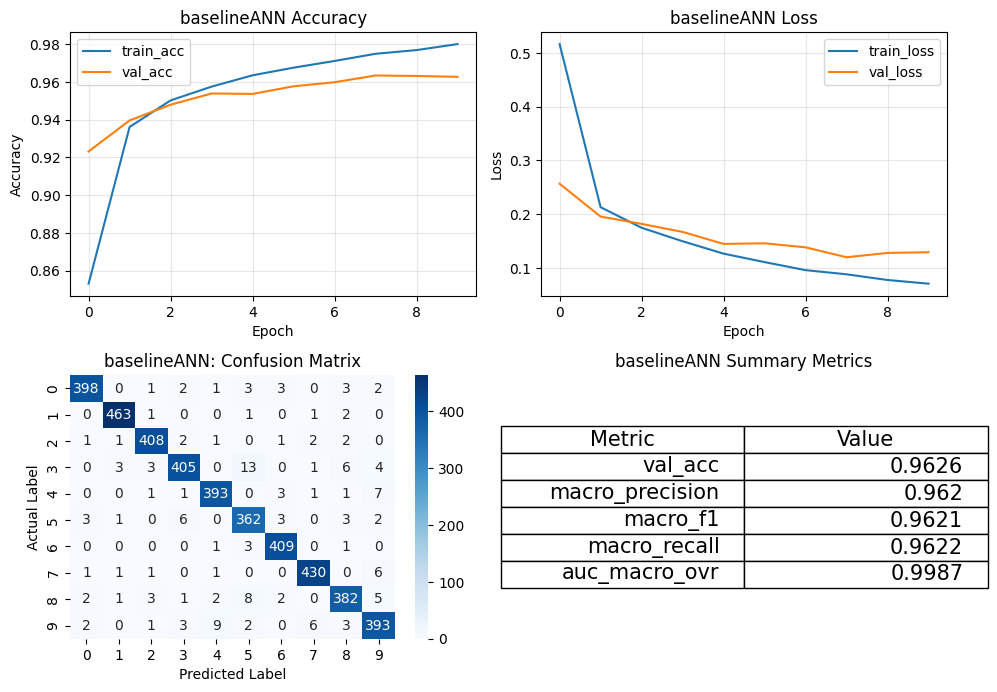

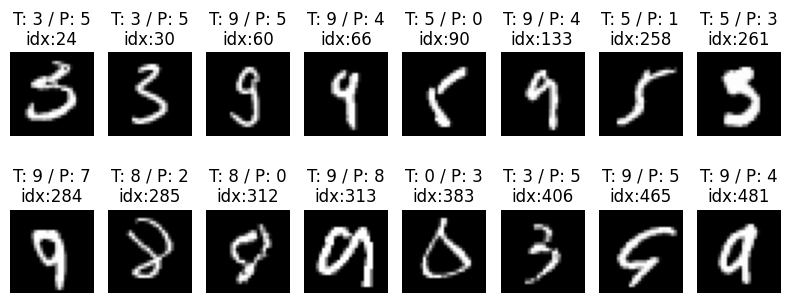

In [12]:
# plot model figs and analyze
getFigures(annBaseResults["baselineANN"], "baselineANN")

# get misclassified ANN validation samples
ann_yPred = annBaseResults["baselineANN"]["y_val_pred"]
ann_misIdx = np.where(yVal != ann_yPred)[0]

x_mis = xVal[ann_misIdx]
y_true_mis = yVal[ann_misIdx]
y_pred_mis = ann_yPred[ann_misIdx]

target_digits = [0, 3, 5, 8, 9]
mask = np.isin(y_true_mis, target_digits)

x_mis_dig = x_mis[mask]
y_true_dig = y_true_mis[mask]
y_pred_dig = y_pred_mis[mask]
mis_idx_dig = ann_misIdx[mask]

plot_misclassified(x_mis_dig, y_true_dig, y_pred_dig, mis_idx_dig, n=16)

## placeholder
#### Taking a look the ANN's performance, we see it had a lot of issues with rounder digits, misclassifying them much more often than the CNN

The ANN had the most trouble with 5s (362 correct), and 8s (373 correct)<br>

&emsp; 5s were most confused with 3s (13 misclassifications) and 8s (8 misclassification); We can also see some confusion with 6s<br>
&emsp; 8s were confused with 0s, 3s and 9s, each having 3 misclassification<br>
&emsp; 9s are also showsn to be an issue, particularly confused with the digits 4 and 7

This is likely due to the digits curvature . . .

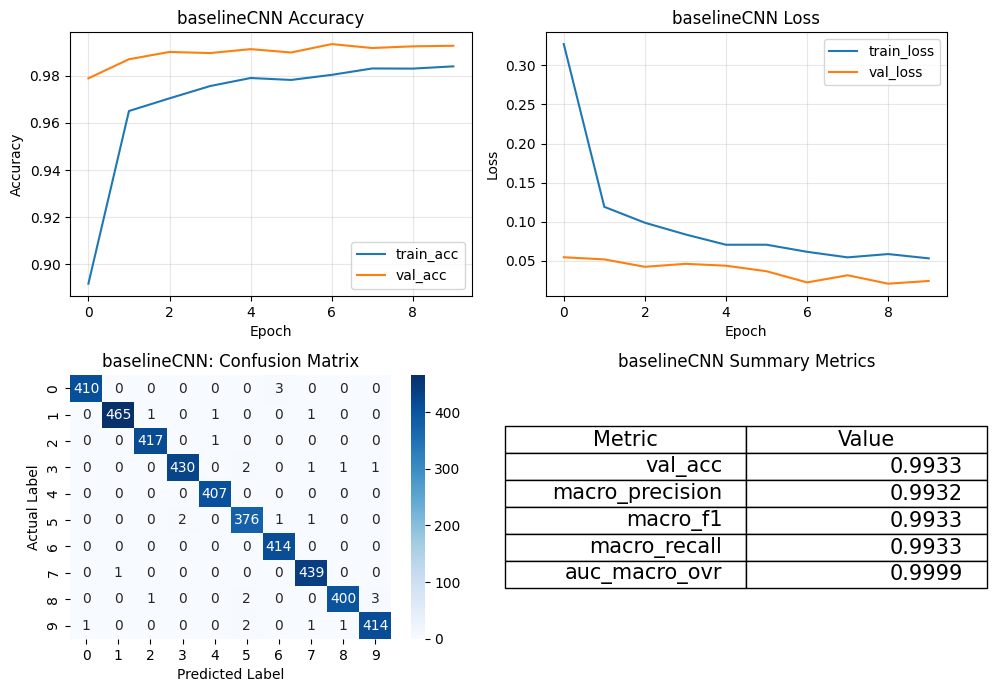

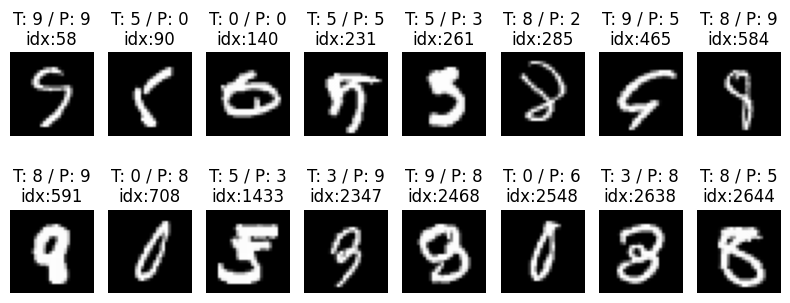

In [13]:
# plot model figs and analyze
getFigures(cnnBaseResults["baselineCNN"], "baselineCNN")

# get misclassified ANN validation samples
cnn_yPred = cnnBaseResults["baselineCNN"]["y_val_pred"]
cnn_misIdx = np.where(yVal != cnn_yPred)[0]

x_mis = xVal[cnn_misIdx]
y_true_mis = yVal[cnn_misIdx]
y_pred_mis = ann_yPred[cnn_misIdx]

target_digits = [0, 3, 5, 8, 9]
mask = np.isin(y_true_mis, target_digits)

x_mis_dig = x_mis[mask]
y_true_dig = y_true_mis[mask]
y_pred_dig = y_pred_mis[mask]
mis_idx_dig = cnn_misIdx[mask]

plot_misclassified(x_mis_dig, y_true_dig, y_pred_dig, mis_idx_dig, n=16)

## placeholder

#### Looking at the CNN's performance, we see it had a less issues with misclassifications, but the patterns are relatively the same



## Placeholder 
### Total Baseline Observations & Next Step: 

As expected, the CNN outperformed the ANN by a wide margin due to its edge detection and 2D spatial input<br>

We can see that both of the models struggle the most with misclassifications of curved numbers: 3s, 5s and 8s.

6 misclassifications between 8 (p) and 9 (t)
3 per 2,3 (p) and 7 (t) // something something patterns

# Section IV: [Direct Augmentation for Error Correction]

> PLACEHOLDER: We will experiment with validation splits and created a targeted augmentation pipeline on the weakest / most misclassified samples to compare performance


### likely issues: 
#### 0 v 6: loop closure, digit thickness, unstable translations
#### 8 v 9: upper and lower loops, rotation, off-centering
#### 3 v (5, 8): stroke curves, slanting, thickness, partial curves

given these observed issues, we want to try small geometric distortions

### Directed Augmentation Setup

In [14]:
def augment_subset(xData, yLabels, datagen, copies=1, batch_size=128):
    x_aug_all = []
    y_aug_all = []

    for _ in range(copies):
        flow = datagen.flow(xData, yLabels, batch_size=batch_size, shuffle=False)
        num_batches = math.ceil(len(xData) / batch_size)

        x_aug_parts = []
        y_aug_parts = []

        for _ in range(num_batches):
            xb, yb = next(flow)
            x_aug_parts.append(xb)
            y_aug_parts.append(yb)

        x_aug = np.concatenate(x_aug_parts, axis=0)[:len(xData)]
        y_aug = np.concatenate(y_aug_parts, axis=0)[:len(yLabels)]

        x_aug_all.append(x_aug)
        y_aug_all.append(y_aug)

    x_aug_all = np.concatenate(x_aug_all, axis=0)
    y_aug_all = np.concatenate(y_aug_all, axis=0)
    
    return x_aug_all, y_aug_all
    

def targeted_augmentation(configs, x_target_cnn, y_target, xTrain, yTrain, xVal, yVal):
    best_config = {"score" : -1.0}
    all_results = []

    x_train_cnn = xTrain.reshape(-1, 28, 28, 1)
    x_val_cnn = xVal.reshape(-1, 28, 28, 1)

    baseline_datagen = make_datagen()
    
    for cfg in configs:
        target_datagen = ImageDataGenerator(
            rotation_range=cfg["r"],
            width_shift_range=cfg["t"],
            height_shift_range=cfg["t"], 
            zoom_range=cfg["z"],
            shear_range=cfg["s"],
        )
        
        x_target_aug, y_target_aug = augment_subset(x_target_cnn, y_target, target_datagen, copies=1)
        
        x_train_targeted = np.concatenate([x_train_cnn, x_target_aug], axis=0)
        y_train_targeted = np.concatenate([yTrain, y_target_aug], axis=0)

        train_flow = baseline_datagen.flow(
            x_train_targeted, y_train_targeted, batch_size=128, shuffle=True)
        
        model = baselineCNN()
        hist = model.fit(train_flow, validation_data=(x_val_cnn, yVal), epochs=10, callbacks=make_callbacks(), verbose=1)

        result = collect_results(model, hist, x_val_cnn, yVal)
        result.update({"name" : cfg["name"],
                  "score" : result["val_acc"],
                  "r" : cfg["r"],
                  "t" : cfg["t"],
                  "z" : cfg["z"],
                  "s" : cfg["s"],
        })
        
        all_results.append(result)
        
        if(result["score"] > best_config["score"]): 
            best_config = result.copy()

        del model
        back.clear_session()
        gc.collect()
        clear_output(wait=True)

    print(f"Best Augment Config Score: {best_config['score']:.4f}")
    return best_config, all_results

### Direct Augmentation Training & Results

In [15]:
target_digits = [0, 3, 5, 6, 8, 9]
target_mask = np.isin(yTrain, target_digits)
x_target = xTrain[target_mask]
y_target = yTrain[target_mask]

x_target_cnn = x_target.reshape(-1, 28, 28, 1)

augment_configs = [
        {"name" : "lowered", "r" : 8, "t" : 0.08, "z" : 0.08, "s" : 0.05},
        {"name" : "raised", "r" : 10, "t" : 0.12, "z" : 0.12, "s" : 0.05},
        {"name" : "max", "r" : 15, "t" : 0.12, "z" : 0.12, "s" : 0.08}
    ]

best_aug_cfg, aug_results = targeted_augmentation(
    augment_configs, x_target_cnn, y_target, xTrain, yTrain, xVal, yVal)

Best Augment Config Score: 0.9845


In [16]:
# make any observations on targeted aug performance
# -- "targeted clas augmentation via oversampling weak classes,
# --- followed by standard augmentation pipeline
# show misclassified images, confusion matrix, and accuracy
# did total mistakes drop, confusion pairs improve, new ones appear, digits improve?

best_aug_cfg["name"]

'lowered'

In [17]:
# observations on targeted augmentation
# view cms and misclassed digits

# Section V: [Exploring Model Optimization]

> Given the margin in performance of the ANN compared to the CNN (96%-97% vs 99%),
> we will focus on exploring areas of improvement for the CNN and optimizing it

**This section:**
1. Explores model pooling architecture -- What effect does preserving spatial data have on the mistakes the model makes?
1. Refines model depth & filter architecture -- Adding conv blocks, filter counts, density, dropouts, and batchnormalization
1. Identifies optimal hyperparameters -- Running a gridsearch to find the optimal batchsize, learning rate, epoch count, 

### Model Configuration & Results Setup

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# ModelCheckpoint for smaller pass : ModelCheckpoint(f"{name}.keras", monitor='val_accuracy', save_best_only=True, mode='max'
def ref_callbacks(name=None):
  return [EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, mode='max'), ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)]


# soft and return top-performing configurations during model optimization
def get_top_configs(results, n=3):
    df = pd.DataFrame.from_dict(results, orient="index").reset_index()
    df = df.rename(columns={"index" : "arch_name"})
    top_df = df.sort_values("val_acc", ascending=False).head(n).reset_index(drop=True)
    top_configs = top_df["config"].tolist()
    return top_df, top_configs

## Model Pooling

In [19]:
# we experiment with cnn optimizatio by exploring model architecture first; 
# then we select the top performers and tune their hyperparameters
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization, Activation

# we want to modify and compare the amount of pooling done (less v baseline v more)
# to test if more spatial data processing improves accuracy
def refine_architecture(num_conv_blocks=2, filter_count=32, dense_units=128, use_batchnorm=False, dropout_rate=0.25, learning_rate=1e-3, pool_type="baseline"):
    model = Sequential()
    model.add(Input(shape=(28,28,1)))

    for i in range(num_conv_blocks):
        filters = filter_count * (2 ** i)

        model.add(Conv2D(filters, 3, padding="same", use_bias=not use_batchnorm))
        if use_batchnorm:
            model.add(BatchNormalization())
        model.add(Activation("relu"))

        model.add(Conv2D(filters, 3, padding="same", use_bias=not use_batchnorm))
        if use_batchnorm:
            model.add(BatchNormalization())
        model.add(Activation("relu"))

        if pool_type == "low":
            if i % 2 == 1 or i == num_conv_blocks - 1:
                model.add(MaxPooling2D())
        else:
            model.add(MaxPooling2D())

        if pool_type == "high":
            model.add(Conv2D(filters, 3, padding="same", activation="relu"))
            model.add(MaxPooling2D())

    model.add(Flatten())
    model.add(Dense(dense_units, activation="relu"))
    model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation="softmax"))

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

### Model Pooling Training

In [21]:
def pool_training(pool_types, xTrain, yTrain, xVal, yVal, xTest):
    allResults = {}
    
    xTr, xV, _ = CNNPipeline(xTrain, xVal, xTest)
    
    for pT in pool_types:
        name = f"pool_{pT}_CNN"
        cfg = {
            "num_conv_blocks": 2,
            "filter_count": 32,
            "dense_units": 128,
            "use_batchnorm": False,
            "pool_type": pT
        }
        model = None
        try:
            model = refine_architecture(**cfg)
            hist = train_w_datagen(model, xTr, yTrain, xV, yVal, epochs=10, batch_size=128, callbacks=make_callbacks())
                
            allResults[name] = collect_results(model, hist, xV, yVal)
            allResults[name]["config"] = {"pool_type" : pT}
        finally:
            cleanup_model(model)

    return allResults

pooling_results = pool_training(["baseline", "low", "high"], xTrain, yTrain, xVal, yVal, xTest)
pool_df, _ = get_top_configs(pooling_results, n=1)

best_pool_type = pool_df.iloc[0]["config"]["pool_type"]
print(best_pool_type)

Epoch 1/10
296/296 [==============================] - 5s 16ms/step - loss: 0.4013 - accuracy: 0.8680 - val_loss: 0.0859 - val_accuracy: 0.9733
Epoch 2/10
296/296 [==============================] - 5s 15ms/step - loss: 0.1312 - accuracy: 0.9597 - val_loss: 0.0540 - val_accuracy: 0.9850
Epoch 3/10
296/296 [==============================] - 5s 16ms/step - loss: 0.0980 - accuracy: 0.9704 - val_loss: 0.0415 - val_accuracy: 0.9864
Epoch 4/10
296/296 [==============================] - 4s 15ms/step - loss: 0.0824 - accuracy: 0.9759 - val_loss: 0.0452 - val_accuracy: 0.9848
Epoch 5/10
296/296 [==============================] - 5s 16ms/step - loss: 0.0746 - accuracy: 0.9774 - val_loss: 0.0433 - val_accuracy: 0.9879
Epoch 6/10
296/296 [==============================] - 5s 16ms/step - loss: 0.0663 - accuracy: 0.9810 - val_loss: 0.0328 - val_accuracy: 0.9890
Epoch 7/10
296/296 [==============================] - 6s 21ms/step - loss: 0.0605 - accuracy: 0.9815 - val_loss: 0.0367 - val_accuracy: 0.9902

In [23]:
# sort results of pooling tests
table = pool_df[["arch_name", "val_acc", "val_loss", "auc_macro_ovr"]].copy()
table["val_acc"] = table["val_acc"].round(4)
table["val_loss"] = table["val_loss"].round(4)
table["auc_nacro_ovr"] = table["auc_macro_ovr"].round(4)

table

,arch_name,val_acc,val_loss,auc_macro_ovr,auc_nacro_ovr
0,pool_baseline_CNN,0.9933,0.0282,0.999885,0.9999


## Placeholder -- observations of pooling tests

> baseline model is still the highest scoring, pooling differences did not help with the errors<br>

## Architecture Refinement

1. Test different architecture configurations (number of conv blocks, total filters, density) with batch normalization
1. Identify the 6 top performers, test architectures again w/o batchnorms
1. Rerank top models with deeper training
1. Save the top 3 configurations for hyperparameter tuning

In [24]:
def train_refined_models(xTr, yTrain, xV, yVal, pool_type="baseline", use_batchnorm=True, epochs=10):
    i = 0
    allResults = {}

    num_conv_blocks = [2, 3, 4]
    filter_count = [32, 64]
    dense_units = [128, 256]
    
    # after configs, we will take the top model and compare its performance with no batchnorm?
    for n in num_conv_blocks:
        for fc in filter_count:
            for du in dense_units:      
                print(f"Refining Archs, Model #{i+1}")
                arch = f"#cb: {n}, fc: {fc}, du: {du}, bn:{use_batchnorm}, pool: {pool_type}"
                cfg = {
                    "num_conv_blocks" : n,
                    "filter_count" : fc,
                    "dense_units" : du,
                    "use_batchnorm" : use_batchnorm,
                    "pool_type" : pool_type,
                }
                model = None
                try:    
                    model = refine_architecture(**cfg)
                    
                    hist = train_w_datagen(model, xTr, yTrain, xV, yVal, epochs=epochs, batch_size=128, callbacks=make_callbacks())
                    
                    allResults[arch] = collect_results(model, hist, xV, yVal)
                    allResults[arch]["config"] = cfg
                finally:
                    i += 1
                    cleanup_model(model)
                
    print("Architecture Exploration completed")
    return allResults

def rerun_no_batchnorm(configs, xTr, yTrain, xV, yVal):
    i = 0
    results = {}
    
    for cfg in configs:
        print(f"No BatchNorm Training, Model #{i+1}")
        cfg_no_bn = cfg.copy()
        cfg_no_bn["use_batchnorm"] = False

        arch = (
            f"#cb:{cfg_no_bn['num_conv_blocks']}, "
            f"fc:{cfg_no_bn['filter_count']}, "
            f"du:{cfg_no_bn['dense_units']}, "
            f"bn:{cfg_no_bn['use_batchnorm']}"
            f"pool:{cfg_no_bn['pool_type']}"
        )

        model = None
        try:       
            model = refine_architecture(**cfg_no_bn)
            hist = train_w_datagen(model, xTr, yTrain, xV, yVal, epochs=10, batch_size=128, callbacks=make_callbacks())
        
            results[arch] = collect_results(model, hist, xV, yVal)
            results[arch]["config"] = cfg_no_bn
        finally:
            i += 1
            cleanup_model(model)
            
    return results

def deep_rerank(configs, xTr, yTrain, xV, yVal, epochs=20, batch_size=128):
    i = 0
    results = {}

    for cfg in configs:
        print(f"Deep Rerank, Model #{i+1}")
        arch = (
            f"#cb:{cfg['num_conv_blocks']}, "
            f"fc:{cfg['filter_count']}, "
            f"du:{cfg['dense_units']}, "
            f"bn:{cfg['use_batchnorm']}, "
            f"bn:{cfg['pool_type']}, "
            f"rerank_ep:{epochs}"
        )
        model = None
        try:
            model = refine_architecture(**cfg)
            hist = train_w_datagen(model, xTr, yTrain, xV, yVal,
                                   epochs=epochs, batch_size=batch_size,
                                   callbacks=make_callbacks()
                                  )
            results[arch] = collect_results(model, hist, xV, yVal)
            results[arch]["config"] = cfg.copy()
        finally:
            i += 1
            cleanup_model(model)
        
    return results

### Architecture Refinement Training - First Pass
> Train models using shallow baseline (10 epochs) & identify top performers

In [25]:
xTr_cnn, xV_cnn, _ = CNNPipeline(xTrain, xVal, xTest)
archResults = train_refined_models(xTr_cnn, yTrain, xV_cnn, yVal, pool_type=best_pool_type, use_batchnorm=True, epochs=10)

# save the top 6 performers, pass to no batchnorms
top6_df, top6_configs = get_top_configs(archResults, n=6)

# test models w/o batchnorms
print("Rerunning with no batchnorm")
no_bn_results = rerun_no_batchnorm(top6_configs, xTr_cnn, yTrain, xV_cnn, yVal)

Refining Archs, Model #1
Epoch 1/10
296/296 [==============================] - 6s 18ms/step - loss: 1.5460 - accuracy: 0.4741 - val_loss: 1.9022 - val_accuracy: 0.3417
Epoch 2/10
296/296 [==============================] - 5s 17ms/step - loss: 0.8101 - accuracy: 0.6882 - val_loss: 0.9171 - val_accuracy: 0.6802
Epoch 3/10
296/296 [==============================] - 5s 17ms/step - loss: 0.7187 - accuracy: 0.7235 - val_loss: 0.1872 - val_accuracy: 0.9605
Epoch 4/10
296/296 [==============================] - 5s 18ms/step - loss: 0.6994 - accuracy: 0.7348 - val_loss: 0.2957 - val_accuracy: 0.9326
Epoch 5/10
296/296 [==============================] - 7s 24ms/step - loss: 0.6686 - accuracy: 0.7468 - val_loss: 0.2107 - val_accuracy: 0.9607
Epoch 6/10
296/296 [==============================] - 5s 17ms/step - loss: 0.6337 - accuracy: 0.7597 - val_loss: 0.2059 - val_accuracy: 0.9617
Epoch 7/10
296/296 [==============================] - 5s 17ms/step - loss: 0.6167 - accuracy: 0.7718 - val_loss: 0.13

In [26]:
# combine shallow results
combined = {}
combined.update(archResults)
combined.update(no_bn_results)

refinedShallow_df, refinedShallow_configs = get_top_configs(combined, n=6)

### Architecture Refinement Training - Second Pass
> Train models more deeply (increased epoch count) & identify the top architectures

In [27]:
deep_results = deep_rerank(refinedShallow_configs, xTr_cnn, yTrain, xV_cnn, yVal, epochs=20, batch_size=128)

refinedDeep_df, refinedDeep_configs = get_top_configs(deep_results, n=3)

Deep Rerank, Model #1
Epoch 1/20
296/296 [==============================] - 5s 16ms/step - loss: 0.2841 - accuracy: 0.9092 - val_loss: 0.0591 - val_accuracy: 0.9810
Epoch 2/20
296/296 [==============================] - 5s 15ms/step - loss: 0.0794 - accuracy: 0.9753 - val_loss: 0.0459 - val_accuracy: 0.9860
Epoch 3/20
296/296 [==============================] - 5s 16ms/step - loss: 0.0657 - accuracy: 0.9817 - val_loss: 0.0376 - val_accuracy: 0.9890
Epoch 4/20
296/296 [==============================] - 5s 16ms/step - loss: 0.0522 - accuracy: 0.9830 - val_loss: 0.0274 - val_accuracy: 0.9902
Epoch 5/20
296/296 [==============================] - 5s 16ms/step - loss: 0.0449 - accuracy: 0.9860 - val_loss: 0.0288 - val_accuracy: 0.9917
Epoch 6/20
296/296 [==============================] - 6s 21ms/step - loss: 0.0397 - accuracy: 0.9883 - val_loss: 0.0323 - val_accuracy: 0.9931
Epoch 7/20
296/296 [==============================] - 5s 17ms/step - loss: 0.0383 - accuracy: 0.9880 - val_loss: 0.0302 

In [28]:
# top 3 model metrics
top3_df, top3_configs = get_top_configs(deep_results, n=3)

top3_table = top3_df[["arch_name", "val_acc", "val_loss", "auc_macro_ovr"]].copy()
top3_table["val_acc"] = top3_table["val_acc"].round(4)
top3_table["val_loss"] = top3_table["val_loss"].round(4)
top3_table["auc_macro_ovr"] = top3_table["auc_macro_ovr"].round(4)

top3_table

,arch_name,val_acc,val_loss,auc_macro_ovr
0,"#cb:2, fc:32, du:256, bn:False, bn:baseline, r...",0.9957,0.0213,0.9999
1,"#cb:3, fc:32, du:128, bn:True, bn:baseline, re...",0.9931,0.0324,0.9999
2,"#cb:4, fc:32, du:128, bn:True, bn:baseline, re...",0.9914,0.0241,0.9998


## Section V: [Finalizing Submission]

1. Tune top performing model
1. Compare final model performance to previous models

### Hyperparameter Tuning Setup

In [33]:
# taking the top 3 models from architecture refinement, we move onto tuning the model's hyperparameters
def hyperparam_tuning(topArchs, xTrain, yTrain, xVal, yVal, pool_type="baseline"):
    i = 0
    allResults = {}
    
    # gridsearch the optimal hyperparameters 
    ep = 35 # ceiling
    batch_sizes = [32, 64, 128] # we add 128 for deeper smaller search
    dropout_rates = [0.25, 0.5]
    learning_rates = [1e-3, 5e-4]

    xTr, xV, _ = CNNPipeline(xTrain, xVal, xTest)
    
    for cfg in topArchs:
        for bs in batch_sizes:
            for dr in dropout_rates: 
                for lr in learning_rates:
                    print(f"Hyperparameter Tuning Model #{i+1}")
                    arch = f"#cb:{cfg['num_conv_blocks']}_fc:{cfg['filter_count']}_du:{cfg['dense_units']}_bn:{cfg['use_batchnorm']}_bs:{bs}_dr:{dr}_lr:{lr}"
                    config = {
                        "num_conv_blocks": cfg['num_conv_blocks'], 
                        "filter_count": cfg['filter_count'], 
                        "dense_units": cfg['dense_units'], 
                        "use_batchnorm": cfg['use_batchnorm'], 
                        "batch_size": bs, 
                        "dropout_rate": dr,
                        "learning_rate": lr,
                        "pool_type" : pool_type
                    }

                    model = None
                    try:
                        
                        model = refine_architecture(num_conv_blocks=cfg["num_conv_blocks"],
                                                    filter_count=cfg["filter_count"],
                                                    dense_units=cfg["dense_units"],
                                                    use_batchnorm=cfg["use_batchnorm"],
                                                    dropout_rate=dr,
                                                    learning_rate=lr,
                                                    pool_type=cfg["pool_type"]
                                                   )                    
    
                        hist = train_w_datagen(model, xTr, yTrain, xV, yVal, epochs=ep, batch_size=bs, callbacks=ref_callbacks()) # add back name once main pass done
                        
                        allResults[arch] = collect_results(model, hist, xV, yVal)
                        allResults[arch]["config"] = config
                    finally:
                        i += 1
                        cleanup_model(model)
                
    return allResults 

### HyperParam Results & Final Comparisons

In [ ]:
final_hypers = hyperparam_tuning(top3_configs, xTrain, yTrain, xVal, yVal, pool_type=best_pool_type)

# top 3 hyperparameter model table
finals_df, finals_config = get_top_configs(final_hypers, n=3)

finals_table = finals_df[["arch_name", "val_acc", "val_loss", "auc_macro_ovr"]].copy()
finals_table["val_acc"] = finals_table["val_acc"].round(4)
finals_table["val_loss"] = finals_table["val_loss"].round(4)
finals_table["auc_macro_ovr"] = finals_table["auc_macro_ovr"].round(4)

finals_table

Hyperparameter Tuning Model #1
Epoch 1/35
1182/1182 [==============================] - 19s 15ms/step - loss: 0.2226 - accuracy: 0.9296 - val_loss: 0.0644 - val_accuracy: 0.9864 - lr: 0.0010
Epoch 2/35
1182/1182 [==============================] - 16s 14ms/step - loss: 0.0810 - accuracy: 0.9756 - val_loss: 0.0378 - val_accuracy: 0.9855 - lr: 0.0010
Epoch 3/35
1182/1182 [==============================] - 18s 15ms/step - loss: 0.0619 - accuracy: 0.9814 - val_loss: 0.0463 - val_accuracy: 0.9898 - lr: 0.0010
Epoch 4/35
1182/1182 [==============================] - 17s 14ms/step - loss: 0.0506 - accuracy: 0.9830 - val_loss: 0.0398 - val_accuracy: 0.9893 - lr: 0.0010
Epoch 5/35
1182/1182 [==============================] - 18s 15ms/step - loss: 0.0502 - accuracy: 0.9853 - val_loss: 0.0398 - val_accuracy: 0.9898 - lr: 0.0010
Epoch 6/35
1182/1182 [==============================] - 16s 14ms/step - loss: 0.0314 - accuracy: 0.9905 - val_loss: 0.0270 - val_accuracy: 0.9912 - lr: 5.0000e-04
Epoch 7/35


In [ ]:
# final v refined v baseline model metric / error comparison
comparison_results = {
    "baselineANN": annBaseResults["baselineANN"],
    "baselineCNN": cnnBaseResults["baselineCNN"],
    "targetedCNN": best_aug_cfg,
    "refinedShallowCNN": combined[refinedShallow_df.iloc[0]["arch_name"]],
    "finalCNN": best_final_result
}

comparison_rows = []
for name, r in comparison_results.items():
    report = r["classification_report"]
    comparison_rows.append({
        "model": name,
        "val_acc": r["val_acc"],
        "val_loss": r["val_loss"],
        "auc_macro_ovr": r["auc_macro_ovr"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"]
    })

comparison_table = pd.DataFrame(comparison_rows).sort_values("val_acc", ascending=False).reset_index(drop=True)

for col in ["val_acc", "val_loss", "auc_macro_ovr", "macro_precision", "macro_recall", "macro_f1"]:
    comparison_table[col] = comparison_table[col].round(4)

display(comparison_table)

getFigures(annBaseResults["baselineANN"], "baselineANN")
getFigures(cnnBaseResults["baselineCNN"], "baselineCNN")
getFigures(best_aug_cfg, "targetedCNN")
getFigures(best_final_result, "finalCNN")

comparison_table.plot(x="model", y=["val_acc", "macro_f1", "auc_macro_ovr"],
                      kind="bar", figsize=(10,5),
                      rot=0, title="Final Model Comparison"
)

plt.ylim(0.9, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Kaggle Submission

In [ ]:
# choose best final model
best_final_name = final_hyp_df.iloc[0]["arch_name"]
best_final_config = final_hyp_df.iloc[0]["config"]

# rebuild and retrain final model
xTr_cnn, xV_cnn, _ = CNNPipeline(xTrain, xVal, xTest)

final_model = refine_architecture(
    num_conv_blocks=best_final_cfg["num_conv_blocks"],
    filter_count=best_final_cfg["filter_count"],
    dense_units=best_final_cfg["dense_units"],
    use_batchnorm=best_final_cfg["use_batchnorm"],
    dropout_rate=best_final_cfg["dropout_rate"],
    learning_rate=best_final_cfg["learning_rate"]
)

final_hist = train_w_datagen(
    final_model,
    xTr_cnn, yTrain,
    xV_cnn, yVal,
    epochs=35,
    batch_size=best_final_cfg["batch_size"],
    callbacks=ref_callbacks()
)

final_model_results = collect_results(final_model, final_hist, xV_cnn, yVal)

# predict & save submission
xTest_cnn = xTest.reshape(-1, 28, 28, 1)

pred = np.argmax(finalModel.predict(xTest_cnn, verbose=0), axis=1)

df = pd.DataFrame({"ImageId" : np.arange(1, len(pred) + 1), "Label" : pred})

df.to_csv(SUB_PATH, index=False)
finalModel.save(MODEL_PATH)
print(f"Saved: {SUB_PATH}\nSaved mode: {MODEL_PATH}")